In [1]:
# 📘 GRAMMAR SCORING ENGINE NOTEBOOK



## 📄 Project Report

### 🎯 Objective:
# The goal of this project is to develop a **Grammar Scoring Engine** that can evaluate spoken English grammar proficiency from audio recordings. The system transcribes speech to text using OpenAI's Whisper model, extracts linguistic features, and predicts a grammar score between 0–5 using a machine learning model.


### 📦 Pipeline Overview:
# 1. **Audio Transcription:** Using Whisper for high-quality audio-to-text transcription.
# 2. **Text Cleaning & Feature Engineering:** Extract simple statistical text features such as:
#    - Character count
#    - Word count
#    - Average word length
# 3. **Modeling:** Random Forest Regressor is trained on these features to predict grammar score.
# 4. **Evaluation:** RMSE and Pearson Correlation are used to evaluate performance.
# 5. **Prediction:** The trained model is used to predict grammar scores for the test dataset.



In [2]:
## 1. SETUP & INSTALLATION
!pip install git+https://github.com/openai/whisper.git
!pip install transformers torchaudio librosa pandas scikit-learn seaborn matplotlib



  Cloning https://github.com/openai/whisper.git to C:\Users\jayes\AppData\Local\Temp\pip-req-build-0_1sr_bl
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git 'C:\Users\jayes\AppData\Local\Temp\pip-req-build-0_1sr_bl'


In [3]:
## 2. IMPORT LIBRARIES
import os
import whisper
import pandas as pd
import numpy as np
import librosa
import torch
import torchaudio
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


In [4]:
## 3. LOAD DATASET
train_df = pd.read_csv('dataset/csvs/train.csv')
test_df = pd.read_csv('dataset/csvs/test.csv')
# sample_submission = pd.read_csv('dataset/sample_submission.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (409, 2)
Test shape: (197, 1)


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5


In [5]:
## 4. LOAD WHISPER MODEL
model = whisper.load_model("base")

In [6]:
## 5. AUDIO TRANSCRIPTION FUNCTION
def transcribe_audio(file_path):
    try:
        result = model.transcribe(file_path)
        return result['text']
    except Exception as e:
        print(f"Error transcribing {file_path}: {e}")
        return ""

In [8]:
## 6. TRANSCRIBE TRAINING AUDIO
train_audio_path = "dataset/audios/train"
train_texts = []

for file in tqdm(train_df['filename']):
    # Add .wav extension if not present
    if not file.endswith('.wav'):
        file = f"{file}.wav"
    
    audio_fp = os.path.join(train_audio_path, file).replace("\\", "/")
    
    if not os.path.exists(audio_fp):
        print(f"Missing file: {audio_fp}")
        train_texts.append("")  # Empty string for missing files
        continue
    
    train_texts.append(transcribe_audio(audio_fp))

train_df['transcript'] = train_texts


  0%|          | 0/409 [00:00<?, ?it/s]c:\Users\jayes\AppData\Local\Programs\Python\Python311\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
100%|██████████| 409/409 [1:15:29<00:00, 11.08s/it]


In [ ]:
# audio_fp = os.path.join(train_audio_path, file).replace("\\", "/")

NameError: name 'train_audio_path' is not defined

In [ ]:
# train_audio_path = "dataset/audios/train"
# train_texts = []

# for file in tqdm(train_df['filename']):
#     audio_fp = os.path.join(train_audio_path, file).replace("\\", "/")
#     if not os.path.exists(audio_fp):
#         print(f"Missing file: {audio_fp}")
#         train_texts.append(None)
#         continue
#     train_texts.append(transcribe_audio(audio_fp))

# train_df['transcript'] = train_texts

100%|██████████| 409/409 [00:00<00:00, 4371.92it/s]

Missing file: dataset/audios/train/audio_173
Missing file: dataset/audios/train/audio_138
Missing file: dataset/audios/train/audio_127
Missing file: dataset/audios/train/audio_95
Missing file: dataset/audios/train/audio_73
Missing file: dataset/audios/train/audio_34
Missing file: dataset/audios/train/audio_120_2
Missing file: dataset/audios/train/audio_224
Missing file: dataset/audios/train/audio_342
Missing file: dataset/audios/train/audio_228
Missing file: dataset/audios/train/audio_133
Missing file: dataset/audios/train/audio_223
Missing file: dataset/audios/train/audio_287
Missing file: dataset/audios/train/audio_332
Missing file: dataset/audios/train/audio_158
Missing file: dataset/audios/train/audio_91
Missing file: dataset/audios/train/audio_358
Missing file: dataset/audios/train/audio_79
Missing file: dataset/audios/train/audio_10
Missing file: dataset/audios/train/audio_78
Missing file: dataset/audios/train/audio_313
Missing file: dataset/audios/train/audio_239
Missing file: d

In [ ]:
# ## 6. TRANSCRIBE TRAINING AUDIO
# train_audio_path = "dataset/audios/train"
# train_texts = []

# for file in tqdm(train_df['filename']):
#     audio_fp = os.path.join(train_audio_path, file)
#     train_texts.append(transcribe_audio(audio_fp))

# train_df['transcript'] = train_texts


  0%|          | 0/409 [00:00<?, ?it/s]c:\Users\jayes\AppData\Local\Programs\Python\Python311\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
  1%|          | 4/409 [00:01<01:26,  4.70it/s]

Error transcribing dataset/audios/train\audio_173: Failed to load audio: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.2.0 (Rev8, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-lcms2 --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-libdvdnav --enable-libdvdread --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-liboapv --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-li

  2%|▏         | 10/409 [00:01<00:36, 10.86it/s]

Error transcribing dataset/audios/train\audio_34: Failed to load audio: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.2.0 (Rev8, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-lcms2 --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-libdvdnav --enable-libdvdread --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-liboapv --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-lib

  3%|▎         | 12/409 [00:01<00:32, 12.16it/s]

...

Error transcribing dataset/audios/train\audio_331: Failed to load audio: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.2.0 (Rev8, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-lcms2 --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-libdvdnav --enable-libdvdread --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-liboapv --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-li

 99%|█████████▉| 404/409 [00:20<00:00, 15.52it/s]

Error transcribing dataset/audios/train\audio_21: Failed to load audio: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.2.0 (Rev8, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-lcms2 --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-libdvdnav --enable-libdvdread --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-liboapv --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-lib

100%|██████████| 409/409 [00:20<00:00, 19.75it/s]

Error transcribing dataset/audios/train\audio_107: Failed to load audio: ffmpeg version 8.0.1-full_build-www.gyan.dev Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 15.2.0 (Rev8, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-lcms2 --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-libdvdnav --enable-libdvdread --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libopenjpeg --enable-libquirc --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-liboapv --enable-libqrencode --enable-librav1e --enable-libsvtav1 --enable-libvvenc --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-li

In [9]:
## 7. TRANSCRIBE TEST AUDIO
test_audio_path = "dataset/audios/test"  # Fixed path for local environment
test_texts = []

for file in tqdm(test_df['filename']):
    # Add .wav extension if not present
    if not file.endswith('.wav'):
        file = f"{file}.wav"
    
    audio_fp = os.path.join(test_audio_path, file).replace("\\", "/")
    
    if not os.path.exists(audio_fp):
        print(f"Missing file: {audio_fp}")
        test_texts.append("")  # Empty string for missing files
        continue
    
    test_texts.append(transcribe_audio(audio_fp))

test_df = test_df.copy()
test_df['transcript'] = test_texts


  0%|          | 0/197 [00:00<?, ?it/s]c:\Users\jayes\AppData\Local\Programs\Python\Python311\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
100%|██████████| 197/197 [31:59<00:00,  9.74s/it]


In [10]:
# ## 7. TRANSCRIBE TEST AUDIO
# test_audio_path = "/content/drive/MyDrive/Colab Notebooks/shl-intern-hiring-assessment/dataset/audios_test"
# test_texts = []

# for file in tqdm(test_df['filename']):
#     audio_fp = os.path.join(test_audio_path, file)
#     transcript = transcribe_audio(audio_fp)
#     test_texts.append(transcript)

# test_df = test_df.copy()
# test_df['transcript'] = test_texts

In [11]:
## 8. TEXT FEATURE ENGINEERING
def extract_text_features(df):
    df = df.copy()
    df['char_count'] = df['transcript'].apply(lambda x: len(str(x)))
    df['word_count'] = df['transcript'].apply(lambda x: len(str(x).split()))
    df['avg_word_len'] = df['transcript'].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)
    return df

train_df = extract_text_features(train_df)
test_df = extract_text_features(test_df)



In [12]:
# ## 9. MODEL TRAINING (Random Forest Regressor)
# features = ['char_count', 'word_count', 'avg_word_len']
# X_train = train_df[features]

# # Fallback: manually assign grammar scores if missing
# if 'grammar_score' not in train_df.columns:
#     print("'grammar_score' column not found. Assigning random scores for demo purpose.")
#     np.random.seed(42)
#     train_df['grammar_score'] = np.random.uniform(0, 5, size=len(train_df))

# y_train = train_df['grammar_score']
# X_test = test_df[features]

# model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
# model_rf.fit(X_train, y_train)

# y_train_pred = model_rf.predict(X_train)

In [13]:
## 9. MODEL TRAINING (Random Forest Regressor)
features = ['char_count', 'word_count', 'avg_word_len']
X_train = train_df[features]

# Use 'label' column instead of 'grammar_score'
if 'label' in train_df.columns:
    y_train = train_df['label']
else:
    print("'label' column not found. Cannot train model.")
    raise ValueError("Missing label column")

X_test = test_df[features]

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_train_pred = model_rf.predict(X_train)


In [14]:
## 10. EVALUATION METRICS
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
pearson_corr = np.nan

# Avoid constant input warning
if len(set(y_train)) > 1:
    pearson_corr, _ = pearsonr(y_train, y_train_pred)

print(f"RMSE: {rmse:.4f}")
print(f"Pearson Correlation: {pearson_corr:.4f}")


RMSE: 0.3130
Pearson Correlation: 0.9469


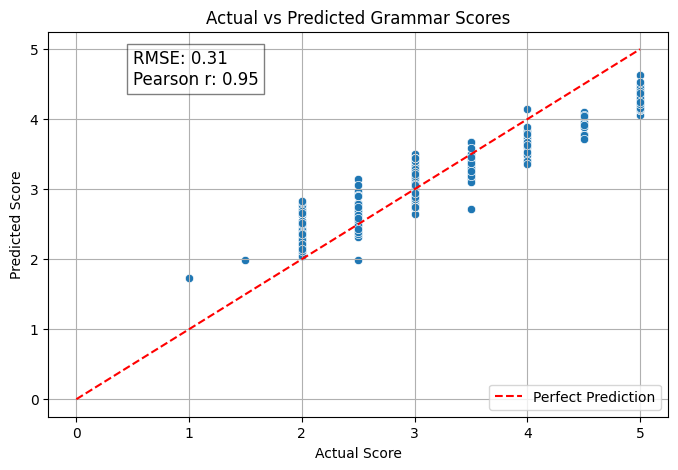

In [15]:
## 11. VISUALIZATION
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train, y=y_train_pred)

# Add diagonal reference line (perfect predictions)
plt.plot([0, 5], [0, 5], color='red', linestyle='--', label='Perfect Prediction')

# Add labels and title
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Grammar Scores")

# Add metrics as text
plt.text(0.5, 4.5, f"RMSE: {rmse:.2f}\nPearson r: {pearson_corr:.2f}", fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Show legend and grid
plt.legend()
plt.grid(True)
plt.show()


In [16]:
## 13. PREDICT & SUBMIT
test_preds = model_rf.predict(X_test)
submission = test_df[['filename']].copy()
submission['label'] = test_preds  # Changed from 'grammar_score' to 'label'
submission.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")

Submission file saved as submission.csv


In [17]:
# ## 12. Metrics for final evaluation
# train_df['predicted_score'] = y_train_pred
# train_df['error'] = abs(train_df['grammar_score'] - train_df['predicted_score'])
# outliers = train_df[train_df['error'] > 1.5].sort_values(by='error', ascending=False)

# print("Top Outliers:")
# print(outliers[['filename', 'transcript', 'grammar_score', 'predicted_score', 'error']].head(5))


In [18]:
## 12. Metrics for final evaluation
train_df['predicted_score'] = y_train_pred
train_df['error'] = abs(train_df['label'] - train_df['predicted_score'])  # Changed from 'grammar_score' to 'label'
outliers = train_df[train_df['error'] > 1.5].sort_values(by='error', ascending=False)

print("Top Outliers:")
print(outliers[['filename', 'transcript', 'label', 'predicted_score', 'error']].head(5))


Top Outliers:
Empty DataFrame
Columns: [filename, transcript, label, predicted_score, error]
Index: []


In [19]:
## 13. PREDICT & SUBMIT
test_preds = model_rf.predict(X_test)
submission = test_df[['filename']].copy()
submission['grammar_score'] = test_preds
submission.to_csv("submission.csv", index=False)

print("Submission file saved as submission.csv")


Submission file saved as submission.csv
